In [210]:
import numpy as np
import pandas as pd
import seaborn as sns


In [211]:
x = np.linspace(-10.0, 10.0, 200)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [212]:
x1 = np.linspace(-5.0, 5.0, 200)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1]) 

In [213]:
labels = np.hstack([np.zeros(len(x)), np.ones(len(x1))])
print(len(x), len(y), len(x1), len(y1), len(labels))

400 400 400 400 800


<Axes: >

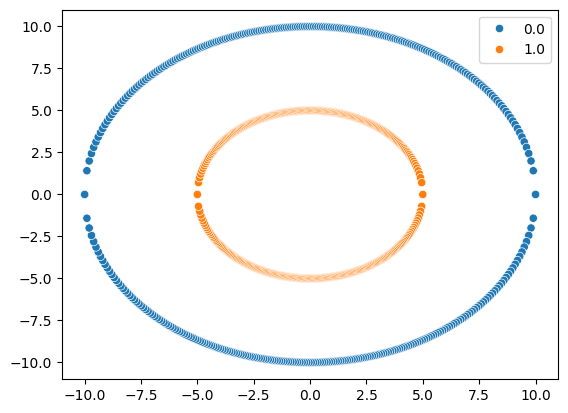

In [214]:
sns.scatterplot(x=np.hstack([x, x1]), y=np.hstack([y, y1]), hue=labels)

In [215]:
df1 = pd.DataFrame(np.vstack([x, y]).T, columns=["X1", "X2"])
df1["Y"] = 0
df2 = pd.DataFrame(np.vstack([x1, y1]).T, columns=["X1", "X2"])
df2["Y"] = 1
df = pd.concat([df1, df2],ignore_index=True)
df.head()

,X1,X2,Y
0,-10.000000,0.000000,0
1,-9.899497,1.414196,0
2,-9.798995,1.994918,0
3,-9.698492,2.437056,0
4,-9.597990,2.806882,0


In [216]:
X = df.iloc[:, :2]
y = df['Y']

In [217]:
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, random_state=42, test_size=0.35)

In [218]:
X_train1

,X1,X2
467,-1.633166,4.725756
319,-1.959799,-9.806079
328,-2.864322,-9.581005
443,-2.839196,4.115698
493,-0.326633,4.989320
...,...,...
71,-2.864322,9.581005
106,0.653266,9.978639
270,2.964824,-9.550383
435,-3.241206,3.807175


In [219]:
df["X1_Square"] = df["X1"] ** 2
df["X2_Square"] = df["X2"] ** 2
df["X1*X2"] = df["X2"] * df["X1"]
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,-10.000000,0.000000,0,100.000000,0.000000,-0.000000
1,-9.899497,1.414196,0,98.000051,1.999949,-13.999827
2,-9.798995,1.994918,0,96.020303,3.979697,-19.548191
3,-9.698492,2.437056,0,94.060756,5.939244,-23.635773
4,-9.597990,2.806882,0,92.121411,7.878589,-26.940429


In [220]:
X = df[['X1', 'X2','X1_Square', 'X2_Square', 'X1*X2']]
y = df['Y']

In [221]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.35)

X_train

,X1,X2,X1_Square,X2_Square,X1*X2
467,-1.633166,4.725756,2.667231,22.332769,-7.717943
319,-1.959799,-9.806079,3.840812,96.159188,19.217944
328,-2.864322,-9.581005,8.204338,91.795662,27.443080
443,-2.839196,4.115698,8.061034,16.938966,-11.685272
493,-0.326633,4.989320,0.106689,24.893311,-1.629677
...,...,...,...,...,...
71,-2.864322,9.581005,8.204338,91.795662,-27.443080
106,0.653266,9.978639,0.426757,99.573243,6.518709
270,2.964824,-9.550383,8.790182,91.209818,-28.315206
435,-3.241206,3.807175,10.505417,14.494583,-12.339839


In [222]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2', color='Y')

fig.show()

In [223]:
from sklearn.svm import SVC

model1 = SVC(kernel='linear')
model1.fit(X_train1, y_train1)
y_pred1 = model1.predict(X_test1)

In [224]:
from sklearn.svm import SVC

model2 = SVC(kernel='linear')
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

In [225]:
from sklearn.svm import SVC

model = SVC(kernel='poly')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [226]:
from sklearn.metrics import accuracy_score

print(f"The accuracy score of the linear model is: {accuracy_score(y_test1, y_pred1)}")
print(f"The accuracy score of the linear model with polynomial feataures is: {accuracy_score(y_test, y_pred2)}")
print(f"The accuracy score of the polynomial model is: {accuracy_score(y_test, y_pred)}")

The accuracy score of the linear model is: 0.5357142857142857
The accuracy score of the linear model with polynomial feataures is: 1.0
The accuracy score of the polynomial model is: 1.0
